In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [2]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### s_s_1

Name: 
Type: Graph
Number of nodes: 18
Number of edges: 21
Average degree:   2.3333


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


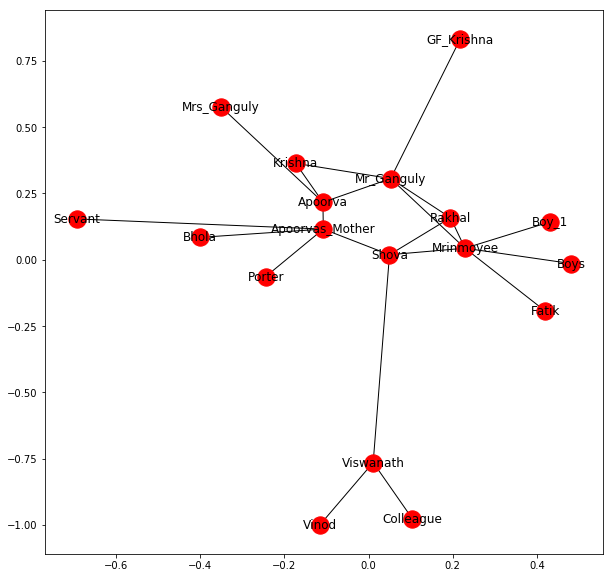

[[('Mrinmoyee', 'Rakhal'), 0.06921487603305784], [('Mrinmoyee', 'Fatik'), 0.011707988980716254], [('Mrinmoyee', 'Boy_1'), 0.023415977961432508], [('Mrinmoyee', 'Boys'), 0.01756198347107438], [('Mrinmoyee', 'Shova'), 0.16190312213039487], [('Mrinmoyee', 'Mr_Ganguly'), 0.014634986225895317], [('Rakhal', 'Mr_Ganguly'), 0.02439164370982553], [('Rakhal', 'Shova'), 0.020890725436179983], [('Shova', 'Apoorvas_Mother'), 0.22675619834710742], [('Shova', 'Viswanath'), 0.004462235996326906], [('Mr_Ganguly', 'GF_Krishna'), 0.0033287419651056014], [('Mr_Ganguly', 'Krishna'), 0.004892676767676767], [('Mr_Ganguly', 'Apoorva'), 0.08930211202938476], [('Apoorvas_Mother', 'Bhola'), 0.020087235996326905], [('Apoorvas_Mother', 'Porter'), 0.03515266299357209], [('Apoorvas_Mother', 'Servant'), 0.005021808999081726], [('Apoorvas_Mother', 'Apoorva'), 0.5230716253443527], [('Apoorva', 'Krishna'), 0.06387741046831956], [('Apoorva', 'Mrs_Ganguly'), 0.00883838383838384], [('Vinod', 'Viswanath'), 0.005222681359044

In [3]:
sm_1 = nx.read_weighted_edgelist('s_m_1.txt', delimiter=',')
print(nx.info(sm_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_1)
plt.show()

total_edge_weight = total_weight_of_G(sm_1) #NCF
w_ncf_1 = weighted_cness(sm_1,total_edge_weight)
print(w_ncf_1)

In [4]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0          (Mrinmoyee, Rakhal)  0.069215
1           (Mrinmoyee, Fatik)  0.011708
2           (Mrinmoyee, Boy_1)  0.023416
3            (Mrinmoyee, Boys)  0.017562
4           (Mrinmoyee, Shova)  0.161903
5      (Mrinmoyee, Mr_Ganguly)  0.014635
6         (Rakhal, Mr_Ganguly)  0.024392
7              (Rakhal, Shova)  0.020891
8     (Shova, Apoorvas_Mother)  0.226756
9           (Shova, Viswanath)  0.004462
10    (Mr_Ganguly, GF_Krishna)  0.003329
11       (Mr_Ganguly, Krishna)  0.004893
12       (Mr_Ganguly, Apoorva)  0.089302
13    (Apoorvas_Mother, Bhola)  0.020087
14   (Apoorvas_Mother, Porter)  0.035153
15  (Apoorvas_Mother, Servant)  0.005022
16  (Apoorvas_Mother, Apoorva)  0.523072
17          (Apoorva, Krishna)  0.063877
18      (Apoorva, Mrs_Ganguly)  0.008838
19          (Vinod, Viswanath)  0.005223
20      (Viswanath, Colleague)  0.006528
          IF
0   0.113454
1   0.019191
2   0.038382
3   0.028787
4   0.265384
5   0.023989
6   0.0

### s_s_2

Name: 
Type: Graph
Number of nodes: 21
Number of edges: 29
Average degree:   2.7619


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


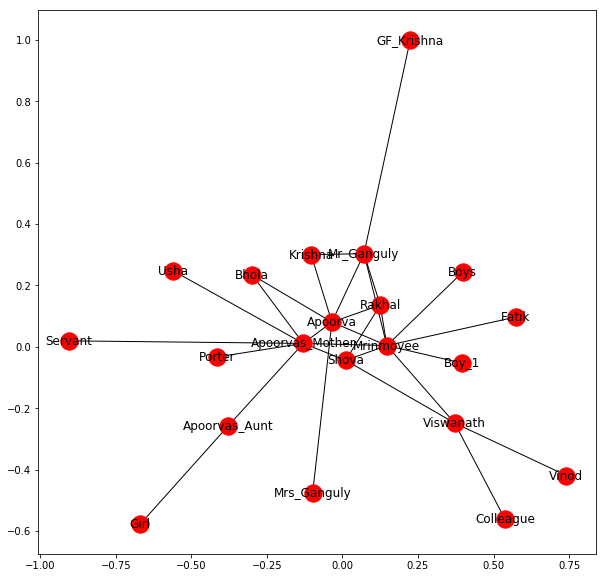

[[('Mrinmoyee', 'Rakhal'), 0.09123795361605992], [('Mrinmoyee', 'Fatik'), 0.014612942892276014], [('Mrinmoyee', 'Boy_1'), 0.029225885784552028], [('Mrinmoyee', 'Boys'), 0.021919414338414024], [('Mrinmoyee', 'Shova'), 0.15602390688895879], [('Mrinmoyee', 'Mr_Ganguly'), 0.014412765592381827], [('Mrinmoyee', 'Viswanath'), 0.060160427807486636], [('Mrinmoyee', 'Apoorvas_Mother'), 0.07817638479796392], [('Mrinmoyee', 'Apoorva'), 0.20932826217506934], [('Rakhal', 'Mr_Ganguly'), 0.022841659755783693], [('Rakhal', 'Shova'), 0.019188424032714688], [('Rakhal', 'Apoorva'), 0.054970116388801504], [('Shova', 'Apoorvas_Mother'), 0.1778432325774257], [('Shova', 'Viswanath'), 0.003739025994452229], [('Mr_Ganguly', 'GF_Krishna'), 0.002337784895192885], [('Mr_Ganguly', 'Krishna'), 0.0035817438302496495], [('Mr_Ganguly', 'Apoorva'), 0.07572421287426005], [('Apoorvas_Mother', 'Bhola'), 0.017815779690583088], [('Apoorvas_Mother', 'Porter'), 0.026823758185821726], [('Apoorvas_Mother', 'Servant'), 0.00383196

In [5]:
sm_2 = nx.read_weighted_edgelist('s_m_2.txt', delimiter=',')
print(nx.info(sm_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_2)
plt.show()

total_edge_weight = total_weight_of_G(sm_2) #NCF
w_ncf_2 = weighted_cness(sm_2,total_edge_weight)
print(w_ncf_2)

In [6]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                               Edges        IF
0                (Mrinmoyee, Rakhal)  0.091238
1                 (Mrinmoyee, Fatik)  0.014613
2                 (Mrinmoyee, Boy_1)  0.029226
3                  (Mrinmoyee, Boys)  0.021919
4                 (Mrinmoyee, Shova)  0.156024
5            (Mrinmoyee, Mr_Ganguly)  0.014413
6             (Mrinmoyee, Viswanath)  0.060160
7       (Mrinmoyee, Apoorvas_Mother)  0.078176
8               (Mrinmoyee, Apoorva)  0.209328
9               (Rakhal, Mr_Ganguly)  0.022842
10                   (Rakhal, Shova)  0.019188
11                 (Rakhal, Apoorva)  0.054970
12          (Shova, Apoorvas_Mother)  0.177843
13                (Shova, Viswanath)  0.003739
14          (Mr_Ganguly, GF_Krishna)  0.002338
15             (Mr_Ganguly, Krishna)  0.003582
16             (Mr_Ganguly, Apoorva)  0.075724
17          (Apoorvas_Mother, Bhola)  0.017816
18         (Apoorvas_Mother, Porter)  0.026824
19        (Apoorvas_Mother, Servant)  0.003832
20        (Ap

### s_s_3

Name: 
Type: Graph
Number of nodes: 21
Number of edges: 30
Average degree:   2.8571


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


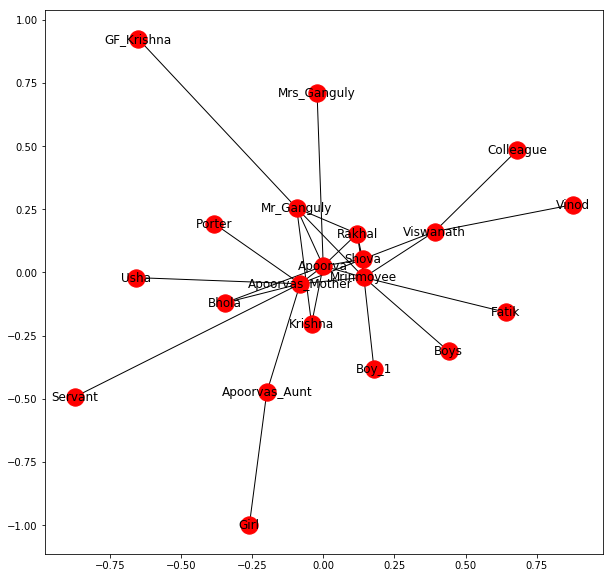

[[('Mrinmoyee', 'Rakhal'), 0.13126040786979098], [('Mrinmoyee', 'Fatik'), 0.010839446632004857], [('Mrinmoyee', 'Boy_1'), 0.021678893264009715], [('Mrinmoyee', 'Boys'), 0.016259169948007284], [('Mrinmoyee', 'Shova'), 0.24495928424379937], [('Mrinmoyee', 'Mr_Ganguly'), 0.010103476694850583], [('Mrinmoyee', 'Viswanath'), 0.04466693120885606], [('Mrinmoyee', 'Apoorvas_Mother'), 0.09047003720548484], [('Mrinmoyee', 'Apoorva'), 0.341442568908153], [('Rakhal', 'Mr_Ganguly'), 0.01626256151453795], [('Rakhal', 'Shova'), 0.014163181832056409], [('Rakhal', 'Apoorva'), 0.03868759941529393], [('Shova', 'Apoorvas_Mother'), 0.13003266078569028], [('Shova', 'Viswanath'), 0.05050720877466093], [('Shova', 'Apoorva'), 0.047132600076649406], [('Mr_Ganguly', 'GF_Krishna'), 0.0016245603681884625], [('Mr_Ganguly', 'Krishna'), 0.0025097592326919884], [('Mr_Ganguly', 'Apoorva'), 0.05339682345878738], [('Apoorvas_Mother', 'Bhola'), 0.01509247106145858], [('Apoorvas_Mother', 'Porter'), 0.0174733507659853], [('A

In [7]:
sm_3 = nx.read_weighted_edgelist('s_m_3.txt', delimiter=',')
print(nx.info(sm_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_3)
plt.show()

total_edge_weight = total_weight_of_G(sm_3) #NCF
w_ncf_3 = weighted_cness(sm_3,total_edge_weight)
print(w_ncf_3)

In [8]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                               Edges        IF
0                (Mrinmoyee, Rakhal)  0.131260
1                 (Mrinmoyee, Fatik)  0.010839
2                 (Mrinmoyee, Boy_1)  0.021679
3                  (Mrinmoyee, Boys)  0.016259
4                 (Mrinmoyee, Shova)  0.244959
5            (Mrinmoyee, Mr_Ganguly)  0.010103
6             (Mrinmoyee, Viswanath)  0.044667
7       (Mrinmoyee, Apoorvas_Mother)  0.090470
8               (Mrinmoyee, Apoorva)  0.341443
9               (Rakhal, Mr_Ganguly)  0.016263
10                   (Rakhal, Shova)  0.014163
11                 (Rakhal, Apoorva)  0.038688
12          (Shova, Apoorvas_Mother)  0.130033
13                (Shova, Viswanath)  0.050507
14                  (Shova, Apoorva)  0.047133
15          (Mr_Ganguly, GF_Krishna)  0.001625
16             (Mr_Ganguly, Krishna)  0.002510
17             (Mr_Ganguly, Apoorva)  0.053397
18          (Apoorvas_Mother, Bhola)  0.015092
19         (Apoorvas_Mother, Porter)  0.017473
20        (Ap

### s_s_4

Name: 
Type: Graph
Number of nodes: 23
Number of edges: 35
Average degree:   3.0435


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


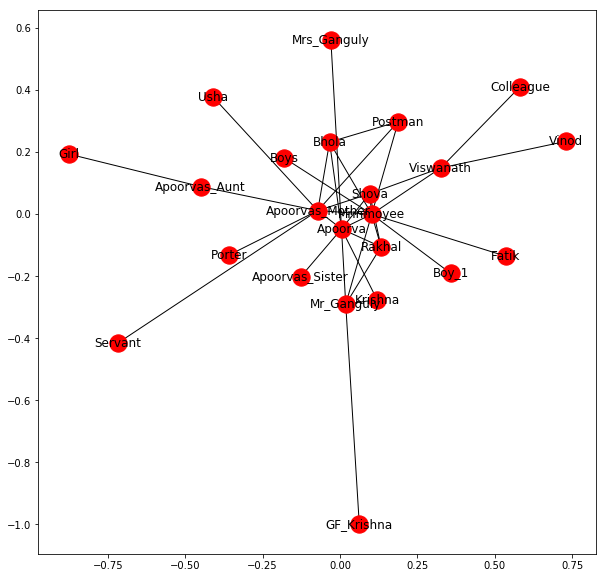

[[('Mrinmoyee', 'Rakhal'), 0.1137192555877677], [('Mrinmoyee', 'Fatik'), 0.009311471763543213], [('Mrinmoyee', 'Boy_1'), 0.018622943527086426], [('Mrinmoyee', 'Boys'), 0.013967207645314818], [('Mrinmoyee', 'Shova'), 0.21151245700015922], [('Mrinmoyee', 'Mr_Ganguly'), 0.00881860070114068], [('Mrinmoyee', 'Viswanath'), 0.03791315864634859], [('Mrinmoyee', 'Apoorvas_Mother'), 0.10334368783821697], [('Mrinmoyee', 'Apoorva'), 0.3581580271003258], [('Mrinmoyee', 'Postman'), 0.01728840034273495], [('Mrinmoyee', 'Bhola'), 0.006141931700708471], [('Rakhal', 'Mr_Ganguly'), 0.014242709931478284], [('Rakhal', 'Shova'), 0.012263643050138889], [('Rakhal', 'Apoorva'), 0.03355820048983801], [('Shova', 'Apoorvas_Mother'), 0.11246559380852844], [('Shova', 'Viswanath'), 0.04283934172646414], [('Shova', 'Apoorva'), 0.040744007825275944], [('Mr_Ganguly', 'GF_Krishna'), 0.0014230072211929502], [('Mr_Ganguly', 'Krishna'), 0.0022545691675028624], [('Mr_Ganguly', 'Apoorva'), 0.046668570749745356], [('Apoorvas_

In [9]:
sm_4 = nx.read_weighted_edgelist('s_m_4.txt', delimiter=',')
print(nx.info(sm_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_4)
plt.show()

total_edge_weight = total_weight_of_G(sm_4) #NCF
w_ncf_4 = weighted_cness(sm_4,total_edge_weight)
print(w_ncf_4)

In [10]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('s_b_t4.csv')
print(df_2)

                               Edges        IF
0                (Mrinmoyee, Rakhal)  0.113719
1                 (Mrinmoyee, Fatik)  0.009311
2                 (Mrinmoyee, Boy_1)  0.018623
3                  (Mrinmoyee, Boys)  0.013967
4                 (Mrinmoyee, Shova)  0.211512
5            (Mrinmoyee, Mr_Ganguly)  0.008819
6             (Mrinmoyee, Viswanath)  0.037913
7       (Mrinmoyee, Apoorvas_Mother)  0.103344
8               (Mrinmoyee, Apoorva)  0.358158
9               (Mrinmoyee, Postman)  0.017288
10                (Mrinmoyee, Bhola)  0.006142
11              (Rakhal, Mr_Ganguly)  0.014243
12                   (Rakhal, Shova)  0.012264
13                 (Rakhal, Apoorva)  0.033558
14          (Shova, Apoorvas_Mother)  0.112466
15                (Shova, Viswanath)  0.042839
16                  (Shova, Apoorva)  0.040744
17          (Mr_Ganguly, GF_Krishna)  0.001423
18             (Mr_Ganguly, Krishna)  0.002255
19             (Mr_Ganguly, Apoorva)  0.046669
20          (